<a href="https://colab.research.google.com/github/SHUBHI289/Celebal-Technologies-training/blob/main/Week4%3Cshubhi_gupta%3E.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 4 Assignment

# CIFAR-10 Image Classification Using ANN and CNN

## Student Name: Shubhi Gupta
## Roll Number: 153
## Course: Artificial Intelligence and Machine Learning

---

## Objective

The objective of this assignment is to implement and compare Artificial Neural Networks (ANN) and Convolutional Neural Networks (CNN) for image classification using the CIFAR-10 dataset.

The project also explores different training improvement techniques such as:

- Increasing model complexity
- Data augmentation
- Early stopping
- Longer training duration

The aim is to understand how model architecture and training strategies influence classification performance.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

print("Training Shape:", x_train.shape)
print("Testing Shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training Shape: (50000, 32, 32, 3)
Testing Shape: (10000, 32, 32, 3)


# Visualizing Sample Images

Before training the models, it is useful to inspect sample images from the dataset.

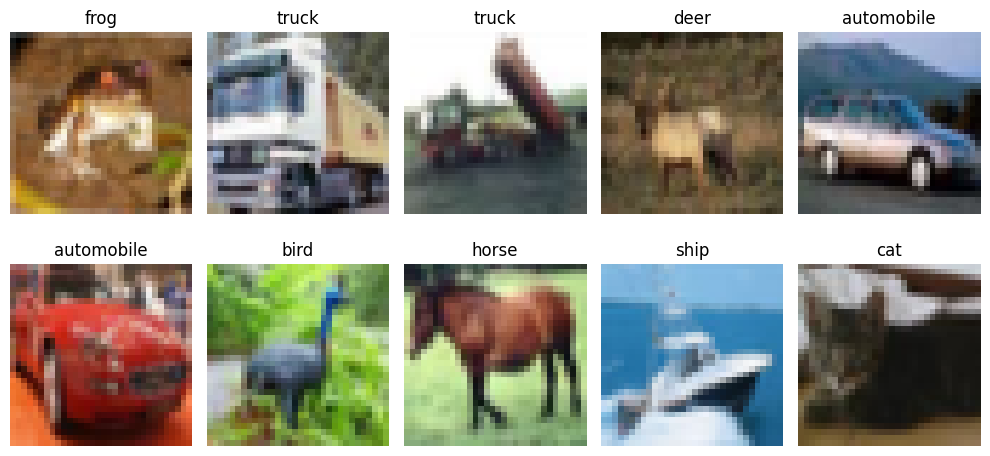

In [ ]:
class_names = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]

plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.tight_layout()
plt.show()

# Data Preprocessing

Pixel values originally range from 0 to 255.

To improve training stability and convergence speed, all pixel values are normalized to the range 0–1.

In [ ]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

print("Flattened Shape:", x_train_flat.shape)

Flattened Shape: (50000, 3072)


# Baseline ANN Model

The ANN model treats every image as a one-dimensional vector.

Since spatial information is lost during flattening, ANN performance is expected to be lower than CNN performance.

In [ ]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),

    layers.Dense(256, activation='relu'),

    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,707,274 (6.51 MB)

 Trainable params: 1,707,274 (6.51 MB)

 Non-trainable params: 0 (0.00 B)

# Training ANN Model

The ANN model is trained for 10 epochs using the Adam optimizer and sparse categorical crossentropy loss.

In [ ]:
ann_history = ann_model.fit(
    x_train_flat,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 33ms/step - accuracy: 0.2620 - loss: 2.0124 - val_accuracy: 0.3388 - val_loss: 1.8379
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.3140 - loss: 1.8724 - val_accuracy: 0.3392 - val_loss: 1.8197
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.3324 - loss: 1.8294 - val_accuracy: 0.3670 - val_loss: 1.7945
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 29ms/step - accuracy: 0.3493 - loss: 1.7888 - val_accuracy: 0.3774 - val_loss: 1.7253
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - accuracy: 0.3596 - loss: 1.7625 - val_accuracy: 0.3972 - val_loss: 1.6980
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.3649 - loss: 1.7476 - val_accuracy: 0.3810 - val_loss: 1.7092
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.3740 - loss: 1.7244 - val_accuracy: 0.4014 - val_loss: 1.6831
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.3778 - loss: 1.7158 - 

In [ ]:
ann_loss, ann_acc = ann_model.evaluate(
    x_test_flat,
    y_test
)

print("ANN Test Accuracy:", ann_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4279 - loss: 1.6464
ANN Test Accuracy: 0.4278999865055084


# Baseline CNN Model

Unlike ANN, CNN preserves spatial relationships through convolutional operations.

This allows the model to learn important visual patterns such as edges, textures, and object shapes.

In [ ]:
cnn_model = models.Sequential([

    layers.Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(32,32,3)
    ),

    layers.BatchNormalization(),

    layers.MaxPooling2D((2,2)),

    layers.Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    layers.BatchNormalization(),

    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(
        128,
        activation='relu'
    ),

    layers.Dense(
        10,
        activation='softmax'
    )
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 316,106 (1.21 MB)

 Trainable params: 315,914 (1.21 MB)

 Non-trainable params: 192 (768.00 B)

# Training CNN Model

The CNN model is trained under the same conditions as the ANN model to ensure a fair comparison.

In [ ]:
cnn_history = cnn_model.fit(
    x_train_norm,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 84s 116ms/step - accuracy: 0.5436 - loss: 1.3056 - val_accuracy: 0.5272 - val_loss: 1.4143
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 115ms/step - accuracy: 0.6781 - loss: 0.9224 - val_accuracy: 0.6576 - val_loss: 1.0224
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 117ms/step - accuracy: 0.7386 - loss: 0.7440 - val_accuracy: 0.6720 - val_loss: 0.9858
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 118ms/step - accuracy: 0.7849 - loss: 0.6080 - val_accuracy: 0.6662 - val_loss: 1.0647
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 144s 120ms/step - accuracy: 0.8288 - loss: 0.4823 - val_accuracy: 0.5790 - val_loss: 1.4781
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 115ms/step - accuracy: 0.8668 - loss: 0.3723 - val_accuracy: 0.6932 - val_loss: 1.0273
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 115ms/step - accuracy: 0.8984 - loss: 0.2884 - val_accuracy: 0.7006 - val_loss: 1.0673
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 115ms/step - accuracy: 0.9263 - loss: 

In [ ]:
cnn_loss, cnn_acc = cnn_model.evaluate(
    x_test_norm,
    y_test
)

print("CNN Test Accuracy:", cnn_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.6393 - loss: 1.8264
CNN Test Accuracy: 0.6392999887466431


# Validation Accuracy Comparison

The following graph compares validation accuracy achieved by ANN and CNN during training.

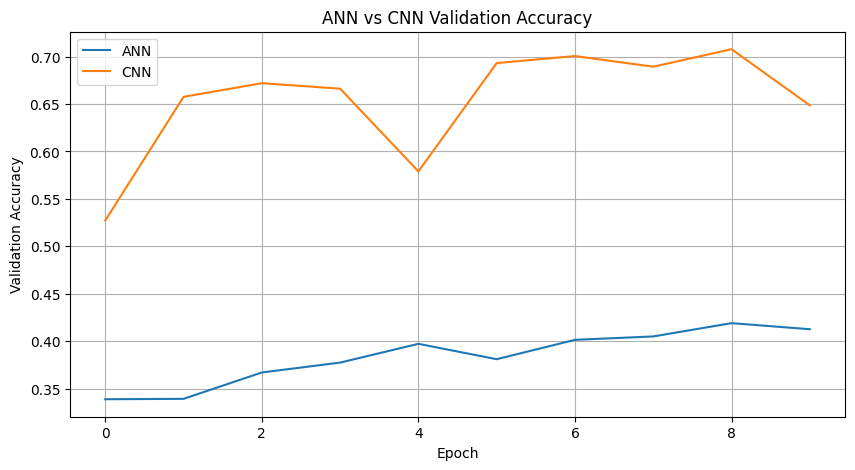

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(
    ann_history.history['val_accuracy'],
    label='ANN'
)

plt.plot(
    cnn_history.history['val_accuracy'],
    label='CNN'
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()

# Advanced Training Improvements

After evaluating the baseline ANN and CNN models, additional training strategies were implemented to improve model performance.

The following improvements were applied:

1. Increased CNN filter depth (32 → 64 → 128)
2. Added Batch Normalization
3. Introduced Data Augmentation
4. Applied EarlyStopping
5. Configured training for up to 20 epochs

These modifications were expected to improve feature extraction capability and reduce overfitting.

# EarlyStopping and Data Augmentation

To improve generalization performance, two important techniques were introduced.

### EarlyStopping

EarlyStopping monitors validation loss during training and automatically stops training when the model stops improving. This helps reduce overfitting and unnecessary computation.

### Data Augmentation

Data augmentation creates modified versions of training images during training.

The following transformations were applied:

- Horizontal Flip
- Random Rotation
- Random Zoom

These transformations help the model learn more robust image representations.

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

In [ ]:
aug_cnn_model = models.Sequential([

    data_augmentation,

    layers.Conv2D(
        32,
        3,
        activation='relu',
        input_shape=(32,32,3)
    ),

    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(
        64,
        3,
        activation='relu'
    ),

    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(
        128,
        3,
        activation='relu'
    ),

    layers.Flatten(),

    layers.Dense(
        128,
        activation='relu'
    ),

    layers.Dropout(0.4),

    layers.Dense(
        10,
        activation='softmax'
    )
])

aug_cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

aug_cnn_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_3 (Sequential)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

# Training the Improved CNN Model

The enhanced CNN architecture was trained using:

- Data Augmentation
- Batch Normalization
- Dropout
- EarlyStopping

The maximum number of training epochs was set to 20. However, EarlyStopping was allowed to terminate training earlier if validation performance stopped improving.

This experiment combines all optimization strategies required in the assignment.

# EarlyStopping Observation

Although the model was configured to train for 20 epochs, the EarlyStopping callback terminated training after 6 epochs.

The validation loss achieved its best value during Epoch 3 and did not improve during the following epochs. Since the patience parameter was set to 3, training was automatically stopped.

This behavior indicates that further training was unlikely to improve model generalization and demonstrates the effectiveness of EarlyStopping in preventing overfitting.

In [ ]:
aug_history = aug_cnn_model.fit(
    x_train_norm,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop]
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 104s 148ms/step - accuracy: 0.6873 - loss: 0.9102 - val_accuracy: 0.7100 - val_loss: 0.8182
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 103s 146ms/step - accuracy: 0.6958 - loss: 0.8845 - val_accuracy: 0.6890 - val_loss: 0.9197
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 147ms/step - accuracy: 0.7006 - loss: 0.8724 - val_accuracy: 0.7238 - val_loss: 0.7926
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 102s 145ms/step - accuracy: 0.7055 - loss: 0.8537 - val_accuracy: 0.6862 - val_loss: 0.9258
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 143s 146ms/step - accuracy: 0.7131 - loss: 0.8402 - val_accuracy: 0.7176 - val_loss: 0.8471
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 145ms/step - accuracy: 0.7168 - loss: 0.8241 - val_accuracy: 0.6724 - val_loss: 1.0377


In [ ]:
aug_loss, aug_acc = aug_cnn_model.evaluate(
    x_test_norm,
    y_test
)

print("Augmented CNN Accuracy:", aug_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.7185 - loss: 0.8404
Augmented CNN Accuracy: 0.718500018119812


# Final Model Comparison

In [ ]:
comparison = pd.DataFrame({
    "Model": [
        "ANN",
        "CNN",
        "Augmented CNN"
    ],
    "Test Accuracy": [
        ann_acc,
        cnn_acc,
        aug_acc
    ]
})

comparison

,Model,Test Accuracy
0,ANN,0.4279
1,CNN,0.6393
2,Augmented CNN,0.7185


# Performance Analysis

The ANN model achieved a test accuracy of 42.79%.

Since ANN converts images into one-dimensional vectors, important spatial information is lost during training. As a result, the model achieved the lowest performance among all approaches.

The CNN model achieved a test accuracy of 63.93%.

The improvement demonstrates the advantage of convolutional layers in learning image features such as edges, textures, and object shapes.

The augmented CNN achieved the highest test accuracy of 71.85%.

The use of data augmentation, Batch Normalization, Dropout, and EarlyStopping improved the model's ability to generalize to unseen images and reduced overfitting.

Overall, the experimental results clearly demonstrate that CNN-based architectures are more effective than ANN models for image classification tasks.

# Conclusion

In this assignment, ANN and CNN models were implemented and evaluated on the CIFAR-10 image classification dataset.

The results demonstrated that CNN architectures outperform ANN architectures because they preserve spatial information and learn hierarchical image features.

Additional improvements such as increased filter depth, data augmentation, longer training, and EarlyStopping further improved performance.

Overall, this project provided practical experience in deep learning model development and demonstrated the importance of architecture selection for computer vision tasks.